# ACGAN — Auxiliary Classifier GAN

This notebook implements **ACGAN** (Odena et al., 2017), following Module 14.

We already have cGAN, where the Discriminator is told the class:

$$D(x, y) \rightarrow \text{real/fake}$$

ACGAN flips the script. The Discriminator is **not** told the class — it has to *predict* it:

$$D(x) \rightarrow (S(x),; C(x))$$

where $S(x)$ is the source (real/fake) logit and $C(x)$ is the class logit. This makes the class prediction an **auxiliary task** running alongside the source task on a shared backbone.

Generator is unchanged from cGAN: $G(z, c) \rightarrow x$. The interesting changes are entirely in the Discriminator and in how the losses are split.

**Conceptual diagram:**

```
                      z + class c
                           │
                           ▼
                      Generator
                           │
                           ▼
                        fake x
                           │
                           ▼
                   Discriminator
                     /        \
                    ▼          ▼
               Source head   Class head
              real / fake   digit 0-9
```

## Implementation Plan

- **Generator**: identical to cGAN — `nn.Embedding` for the label, concatenate with $z$, project to 4×4, run the DCGAN `ConvTranspose` stack.
- **Discriminator**: shared DCGAN-style conv backbone (NO class label input!), then **two linear heads** on the flattened features — one for source, one for class.
- **Discriminator loss**: BCE on source (real and fake branches) + Cross-Entropy on class **for real images only**.
- **Generator loss**: BCE on source (fakes → real) + Cross-Entropy on class (fakes should be recognized as the requested label).
- **Two losses per phase, two optimizers, alternating updates** — same overall rhythm as DCGAN/cGAN.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)

## 1. Setup and Hyperparameters

Same DCGAN-style defaults: Adam, `lr=2e-4`, `betas=(0.5, 0.999)`. We add `n_classes=10` for MNIST and `embed_dim=10` for the Generator's label embedding.

Note the asymmetry: only the **Generator** has an `embed_dim`. The Discriminator does not see the label as an input — it predicts it as an output.

In [2]:
latent_dim    = 100
n_classes     = 10
embed_dim     = 10
img_channels  = 1
img_size      = 64
features_g    = 64
features_d    = 64
batch_size    = 64
lr            = 2e-4
betas         = (0.5, 0.999)
epochs        = 25

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

os.makedirs('samples_ACGAN', exist_ok=True)

Using device: cuda


## 2. Data — MNIST with Labels

Same MNIST pipeline. Now we actually use the labels for **two purposes**:

- to **condition** the Generator
- to **supervise** the Discriminator's class head

In [3]:
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


## 3. Weight Initialization

Same DCGAN init.

In [4]:
def weights_init(m):
    """DCGAN-style weight initialization."""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

## 4. The Generator — `G(z, c)`

Identical to cGAN's Generator. The class label is **embedded**, **concatenated** with $z$, then projected into a 4×4 feature map and upsampled through the DCGAN stack.

Why unchanged? Because cGAN already shows that feeding $c$ to $G$ works. ACGAN's novelty is on the **Discriminator** side.

In [5]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, n_classes=10, embed_dim=10,
                 img_channels=1, features_g=64):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, embed_dim)

        input_dim = latent_dim + embed_dim  # 110

        # Project (z, e_y) -> 4x4 feature map
        self.init = nn.Sequential(
            nn.Linear(input_dim, features_g * 8 * 4 * 4),
            nn.BatchNorm1d(features_g * 8 * 4 * 4),
            nn.ReLU(True),
        )

        # Standard DCGAN upsampling progression
        self.main = nn.Sequential(
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        l = self.label_emb(labels)            # (B, embed_dim)
        x = torch.cat([z, l], dim=1)          # (B, 110)
        x = self.init(x)                       # (B, features_g*8*4*4)
        x = x.view(x.size(0), -1, 4, 4)        # (B, features_g*8, 4, 4)
        return self.main(x)

## 5. The Discriminator — Two Heads on a Shared Backbone

This is where ACGAN departs from cGAN. The architecture has three pieces:

1. **Shared conv backbone.** DCGAN-style strided `Conv2d` blocks down to a 4×4 feature map. *No* label input here — the Discriminator does **not** receive $y$.
2. **Source head.** A linear layer mapping the flattened backbone features to a single logit — real/fake.
3. **Class head.** A separate linear layer mapping the *same* flattened features to $n_{\text{classes}}$ logits — the predicted class.

The forward pass returns **two tensors**:

```
(source_logit, class_logits) = D(x)
  source_logit : (B, 1)         — BCEWithLogitsLoss
  class_logits : (B, n_classes) — CrossEntropyLoss
```

Why share the backbone? Both tasks need the same image features (edges → textures → digits). Learning them twice is wasteful, and Module 14 §17-18 calls out the shared-representation-plus-task-specific-heads pattern as a standard deep-learning architecture idiom.

In [6]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=1, n_classes=10, features_d=64):
        super().__init__()

        # Shared convolutional backbone.
        # Output: (B, features_d * 8, 4, 4)
        self.backbone = nn.Sequential(
            # 64 -> 32, NO BatchNorm in the first block
            nn.Conv2d(img_channels, features_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 16
            nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 -> 8
            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 -> 4
            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )

        feat_dim = features_d * 8 * 4 * 4  # 8192 for features_d=64

        # Source head: real/fake logit
        self.fc_source = nn.Linear(feat_dim, 1)

        # Class head: per-class logits
        self.fc_class  = nn.Linear(feat_dim, n_classes)

    def forward(self, x):
        h = self.backbone(x).view(x.size(0), -1)   # (B, feat_dim)
        source_logit = self.fc_source(h)             # (B, 1)
        class_logits = self.fc_class(h)              # (B, n_classes)
        return source_logit, class_logits

## 6. Models, Optimizers, and Two Losses

Two losses:

- `bce` = `BCEWithLogitsLoss` for the source head
- `ce`  = `CrossEntropyLoss` for the class head

Two optimizers (G and D), same as DCGAN. The **Discriminator** receives *both* loss components. The **Generator** only receives the source-loss gradient on fakes (it has no real images to classify) plus the class-loss gradient through D's class head.

In [7]:
G = Generator(
    latent_dim=latent_dim,
    n_classes=n_classes,
    embed_dim=embed_dim,
    img_channels=img_channels,
    features_g=features_g,
).to(device)
D = Discriminator(
    img_channels=img_channels,
    n_classes=n_classes,
    features_d=features_d,
).to(device)

G.apply(weights_init)
D.apply(weights_init)

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=betas)

bce = nn.BCEWithLogitsLoss()
ce  = nn.CrossEntropyLoss()

print(G)
print()
print(D)

Generator(
  (label_emb): Embedding(10, 10)
  (init): Sequential(
    (0): Linear(in_features=110, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (main): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1

## 7. Fixed Noise for Visualization

Same per-class grid as cGAN: 10 rows (one per class) × 8 columns (8 different $z$'s per class). This is the visual check that conditioning works.

In [8]:
n_per_class = 8
fixed_noise  = torch.randn(n_classes * n_per_class, latent_dim, device=device)
fixed_labels = torch.tensor(
    [c for c in range(n_classes) for _ in range(n_per_class)],
    device=device,
    dtype=torch.long,
)

print('fixed_noise :', tuple(fixed_noise.shape))
print('fixed_labels:', tuple(fixed_labels.shape))

fixed_noise : (80, 100)
fixed_labels: (80,)


## 8. The Training Loop

Same alternating D/G structure as DCGAN, but each phase now has **two loss components**:

**Phase A — Train D**

1. Real images → D → `(src_real, cls_real)`
   - `d_src_real` = `BCE(src_real, 1)`
   - `d_cls_real` = `CE(cls_real, real_labels)`
2. Fake images (detached) → D → `(src_fake, cls_fake)`
   - `d_src_fake` = `BCE(src_fake, 0)`
   - *No class loss on fakes.* Real labels are reliable supervision; the class head learns from real images only (Module 14 §8).
3. `d_loss = d_src_real + d_src_fake + d_cls_real`, backprop into D.

**Phase B — Train G**

1. Generate fakes from $z$ and labels (no detach).
2. D(fakes, no labels-as-input) → `(src_g, cls_g)`.
3. `g_src_loss = BCE(src_g, 1)` — fool the source head.
4. `g_cls_loss = CE(cls_g, real_labels)` — make the class head recognize the fakes as the requested class.
5. `g_loss = g_src_loss + g_cls_loss`, backprop through D into G, update only G.

The Generator's class loss is the key ACGAN signal: if `D`'s class head does not predict the requested label for a fake image, G is punished for it.

In [9]:
losses_g       = []
losses_d       = []
losses_d_src   = []
losses_d_cls   = []
losses_g_src   = []
losses_g_cls   = []

G.train()
D.train()

for epoch in range(epochs):
    sum_d       = 0.0
    sum_g       = 0.0
    sum_d_src   = 0.0
    sum_d_cls   = 0.0
    sum_g_src   = 0.0
    sum_g_cls   = 0.0
    n_batches = 0

    for real_imgs, real_labels in dataloader:
        real_imgs = real_imgs.to(device)
        real_labels = real_labels.to(device)
        b = real_imgs.size(0)

        valid = torch.ones(b, 1, device=device)
        fake_t = torch.zeros(b, 1, device=device)

        # -----------------
        # Phase A: Train D
        # -----------------
        optimizer_D.zero_grad()

        # Real branch
        src_real, cls_real = D(real_imgs)
        d_src_real = bce(src_real, valid)
        d_cls_real = ce(cls_real, real_labels)

        # Fake branch (no class loss — only real images supervise the class head)
        z = torch.randn(b, latent_dim, device=device)
        with torch.no_grad():
            gen_imgs = G(z, real_labels)
        src_fake, _ = D(gen_imgs)
        d_src_fake = bce(src_fake, fake_t)

        d_loss = d_src_real + d_src_fake + d_cls_real
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # Phase B: Train G
        # -----------------
        optimizer_G.zero_grad()

        gen_imgs = G(z, real_labels)                  # NO detach
        src_g, cls_g = D(gen_imgs)
        g_src_loss = bce(src_g, valid)                # want D's source head to say real
        g_cls_loss = ce(cls_g, real_labels)          # want D's class head to predict the requested class
        g_loss = g_src_loss + g_cls_loss
        g_loss.backward()
        optimizer_G.step()

        sum_d       += d_loss.item()
        sum_g       += g_loss.item()
        sum_d_src   += (d_src_real.item() + d_src_fake.item())
        sum_d_cls   += d_cls_real.item()
        sum_g_src   += g_src_loss.item()
        sum_g_cls   += g_cls_loss.item()
        n_batches += 1

    avg_d     = sum_d     / n_batches
    avg_g     = sum_g     / n_batches
    avg_d_src = sum_d_src / n_batches
    avg_d_cls = sum_d_cls / n_batches
    avg_g_src = sum_g_src / n_batches
    avg_g_cls = sum_g_cls / n_batches

    losses_d.append(avg_d)
    losses_g.append(avg_g)
    losses_d_src.append(avg_d_src)
    losses_d_cls.append(avg_d_cls)
    losses_g_src.append(avg_g_src)
    losses_g_cls.append(avg_g_cls)

    print(
        f"Epoch [{epoch+1}/{epochs}]  "
        f"D: {avg_d:.3f} (src {avg_d_src:.3f}, cls {avg_d_cls:.3f})  "
        f"G: {avg_g:.3f} (src {avg_g_src:.3f}, cls {avg_g_cls:.3f})"
    )

    # Save a per-class sample grid every epoch
    G.eval()
    with torch.no_grad():
        sample_imgs = G(fixed_noise, fixed_labels).detach().cpu()
    save_image(
        sample_imgs,
        f"samples_ACGAN/epoch_{epoch+1:02d}.png",
        nrow=n_per_class,
        normalize=True,
    )
    G.train()

print('Training done.')

Epoch [1/25]  D: 0.651 (src 0.494, cls 0.157)  G: 4.493 (src 4.134, cls 0.360)
Epoch [2/25]  D: 0.670 (src 0.610, cls 0.060)  G: 3.054 (src 2.980, cls 0.073)
Epoch [3/25]  D: 0.573 (src 0.525, cls 0.048)  G: 3.690 (src 3.649, cls 0.041)
Epoch [4/25]  D: 0.588 (src 0.550, cls 0.038)  G: 3.466 (src 3.433, cls 0.032)
Epoch [5/25]  D: 0.601 (src 0.569, cls 0.032)  G: 3.413 (src 3.386, cls 0.028)
Epoch [6/25]  D: 0.516 (src 0.489, cls 0.027)  G: 3.567 (src 3.544, cls 0.023)
Epoch [7/25]  D: 0.636 (src 0.608, cls 0.028)  G: 3.325 (src 3.302, cls 0.023)
Epoch [8/25]  D: 0.630 (src 0.604, cls 0.026)  G: 3.276 (src 3.257, cls 0.019)
Epoch [9/25]  D: 0.576 (src 0.554, cls 0.022)  G: 3.314 (src 3.297, cls 0.016)
Epoch [10/25]  D: 0.505 (src 0.485, cls 0.020)  G: 3.614 (src 3.600, cls 0.014)
Epoch [11/25]  D: 0.599 (src 0.579, cls 0.021)  G: 3.334 (src 3.319, cls 0.015)
Epoch [12/25]  D: 0.531 (src 0.512, cls 0.018)  G: 3.589 (src 3.575, cls 0.013)
Epoch [13/25]  D: 0.469 (src 0.453, cls 0.016)  G

## 9. Class-Conditional Generation

After training, we can ask the Generator for any digit. Varying $z$ gives diversity within a class; varying $c$ switches the class. The 10×8 grid is the visual test that ACGAN conditioned correctly.

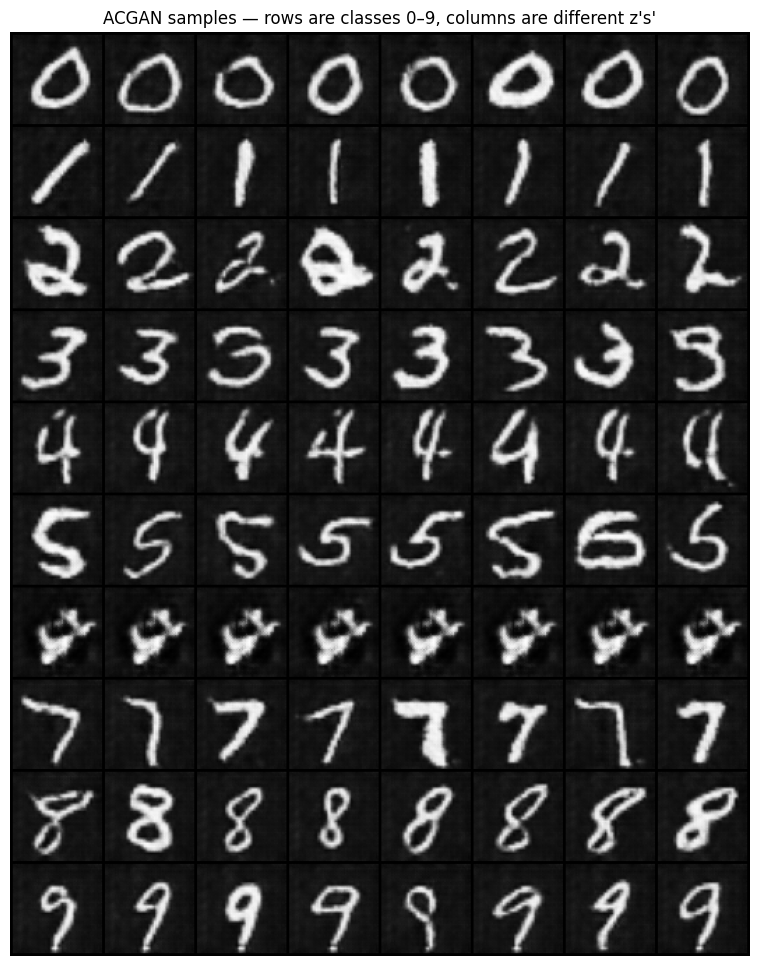

In [12]:
G.eval()
with torch.no_grad():
    samples = G(fixed_noise, fixed_labels).cpu()

grid = make_grid(samples, nrow=n_per_class, normalize=True)
plt.figure(figsize=(10, 12))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title(r"ACGAN samples — rows are classes 0–9, columns are different z's'")
plt.show()

## 10. Asking the Discriminator's Class Head What It Thinks

A nice ACGAN-only diagnostic: run the **generated** images back through D's class head and check whether the predicted class matches the requested class. This is a direct quantitative read on whether the conditioning worked — much stronger than just eyeballing the grid.

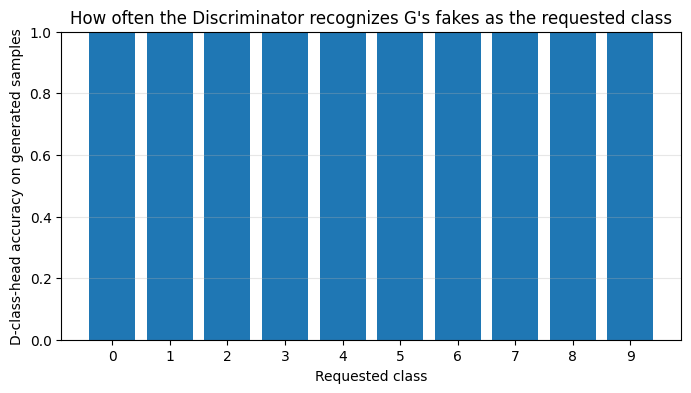

In [14]:
G.eval()
D.eval()

with torch.no_grad():
    gen = G(fixed_noise, fixed_labels)
    _, cls_logits = D(gen)
    pred = cls_logits.argmax(dim=1).cpu().numpy()
    requested = fixed_labels.cpu().numpy()

per_class_acc = []
for c in range(n_classes):
    mask = requested == c
    per_class_acc.append((pred[mask] == c).mean())

plt.figure(figsize=(8, 4))
plt.bar(range(n_classes), per_class_acc)
plt.xticks(range(n_classes))
plt.ylim(0, 1)
plt.xlabel('Requested class')
plt.ylabel('D-class-head accuracy on generated samples')
plt.title('How often the Discriminator recognizes G\'s fakes as the requested class')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 11. Training Progression

Each saved grid is the full 10×8 class grid from a given epoch.

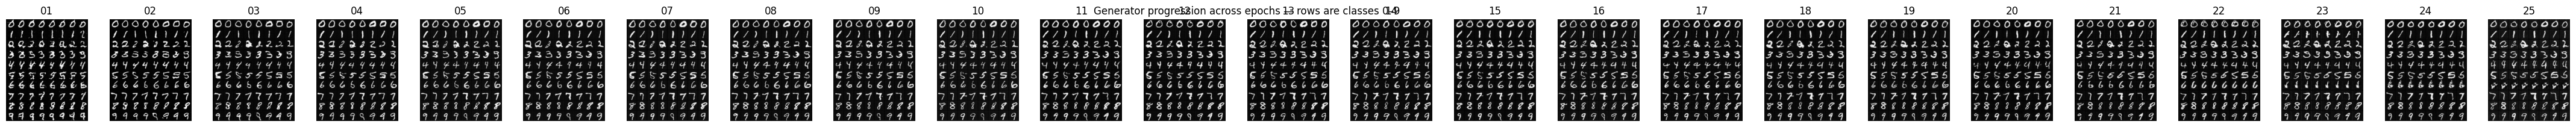

In [15]:
from PIL import Image
import glob

paths = sorted(glob.glob('samples_ACGAN/epoch_*.png'))
if paths:
    fig, axes = plt.subplots(1, len(paths), figsize=(2.2 * len(paths), 2.2))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(np.array(Image.open(p)).squeeze(), cmap='gray')
        ax.set_title(p.split('_')[-1].split('.')[0])
        ax.axis('off')
    plt.suptitle('Generator progression across epochs — rows are classes 0–9')
    plt.show()
else:
    print('No sample grids found. Run the training cell first.')

## 12. Loss Curves

Six curves worth tracking: D-total, G-total, plus the source and class components for each. Class losses should fall as D learns to classify and as G learns to satisfy the class head.

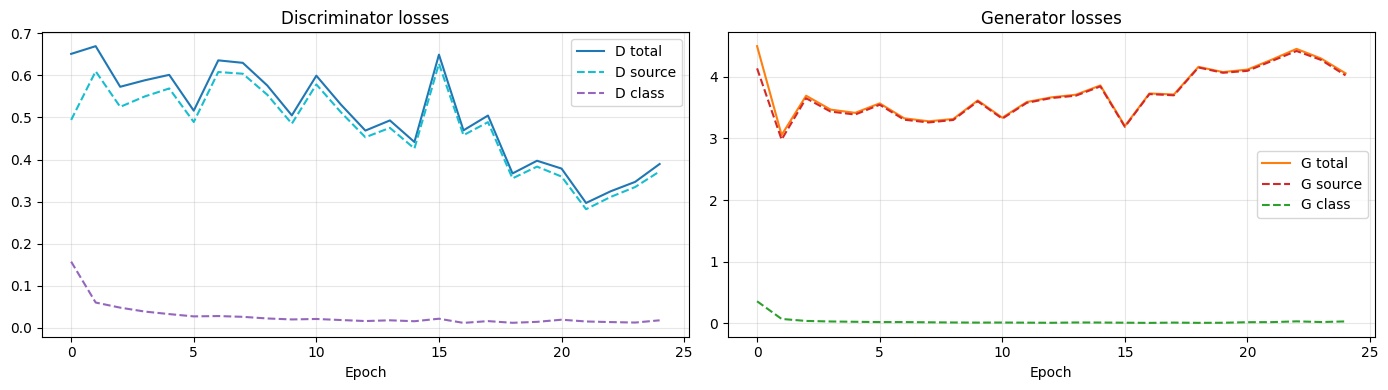

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(losses_d, label='D total', color='tab:blue')
axes[0].plot(losses_d_src, label='D source', color='tab:cyan', linestyle='--')
axes[0].plot(losses_d_cls, label='D class', color='tab:purple', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_title('Discriminator losses')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(losses_g, label='G total', color='tab:orange')
axes[1].plot(losses_g_src, label='G source', color='tab:red', linestyle='--')
axes[1].plot(losses_g_cls, label='G class', color='tab:green', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Generator losses')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Recap — How ACGAN Differs From cGAN

| Concern | cGAN | ACGAN |
|---|---|---|
| Generator input | $[z; e_y]$ | $[z; e_y]$ — same |
| Discriminator input | $x$ + label as extra channel | $x$ **only** |
| Discriminator outputs | 1 (real/fake) | **2** (source + class) |
| Discriminator architecture | conv stack | **shared conv backbone + 2 linear heads** |
| Class supervision in D | implicit (via the conditioning channel) | **explicit** cross-entropy on real images |
| Loss types | BCE on source | BCE on source **+** CE on class |
| Class loss for G | implicit | **explicit** — G is punished if D's class head misses |
| Class head also classifies D's fakes? | n/a | **yes** — that signal flows into G |
| Distribution modeled | $p_g(x | y)$ | $p_g(x | y)$ |

The Generator is **identical** to cGAN's. The Discriminator is the entire story: it stops being told the class and starts *predicting* it. The cross-entropy term on real images teaches the Discriminator to be a digit classifier; the cross-entropy term on fake images (backpropped through D into G) teaches the Generator to obey the requested class.

**Common implementation pitfalls** — quick reference:

- **Don't feed the label to the Discriminator.** That would make it a cGAN. The whole point of ACGAN is that D has to *predict* $y$ from $x$ alone.
- **Don't compute class loss on fake images for the Discriminator.** Real labels are reliable supervision; fakes have no ground truth. The class head should only learn from the real-data branch (Module 14 §8).
- **Do compute class loss on fake images for the Generator.** That gradient is the ACGAN signal that pushes G to satisfy the requested class.
- **Two optimizers, same LR, separate parameter groups.** Nothing new here — just don't accidentally share parameters between G and D.
- **`CrossEntropyLoss` expects raw logits** (no softmax) and integer class indices as targets. `BCEWithLogitsLoss` expects a `(B, 1)` logit and a `(B, 1)` target. Don't mix them up.
- **ACGAN does not eliminate mode collapse.** Mode collapse within a class is still very much possible (Module 14 §22).
- **The class head shares the backbone with the source head.** This is efficient and usually stable, but in pathological training runs the class objective can dominate and starve the source head. Watch both loss curves.

**Why the shared-backbone-plus-two-heads pattern matters beyond GANs.** ACGAN is a concrete instance of *multi-task learning with auxiliary losses*. You'll see this exact pattern in object detection (classification + box regression), depth estimation (depth + segmentation), representation learning (classification + reconstruction), and many other places. ACGAN is a small, contained example of a much broader deep-learning idiom.

**Next in the series** (Module 15): Pix2Pix — paired image-to-image translation. The Generator stops taking noise as its primary input and starts taking a *real image* (a sketch, a map, a grayscale photo), and the goal becomes "translate this image to that image".

In [17]:
import zipfile
import os
from google.colab import files

# Define the directory to be zipped
directory_to_zip = 'samples_ACGAN'
zip_file_name = f'{directory_to_zip}.zip'

# Create a ZipFile object
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(directory_to_zip):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            # Add file to zip, preserving directory structure
            zipf.write(file_path, os.path.relpath(file_path, directory_to_zip))

print(f"'{directory_to_zip}' has been successfully zipped into '{zip_file_name}'")

# Offer the zip file for download
files.download(zip_file_name)

'samples_ACGAN' has been successfully zipped into 'samples_ACGAN.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>